#Preguntas para analisis:
Que variables influyen mas en el puntaje de fatiga mental.
Hay profesiones que tengan una afectacion mayor que otras en cuanto a la fatiga mental?

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('D:/Documentos/Projects_DS/datasets/sleep, screen Time and stress analysis/sleep_mobile_stress_dataset_15000.csv')

In [3]:
df.head()

,user_id,age,gender,occupation,daily_screen_time_hours,phone_usage_before_sleep_minutes,sleep_duration_hours,sleep_quality_score,stress_level,caffeine_intake_cups,physical_activity_minutes,notifications_received_per_day,mental_fatigue_score
0,1,56,Female,Designer,3.26,86,5.31,7.72,3.49,0,35,119,3.57
1,2,46,Female,Teacher,1.85,32,7.36,9.70,3.01,0,16,299,1.91
2,3,32,Female,Designer,3.04,107,4.50,6.38,5.03,0,17,21,6.05
3,4,25,Male,Software Engineer,9.00,36,6.68,5.53,10.00,0,3,220,9.92
4,5,38,Female,Teacher,3.52,56,7.57,6.69,6.71,4,92,167,5.99


In [4]:
df.describe()

,user_id,age,daily_screen_time_hours,phone_usage_before_sleep_minutes,sleep_duration_hours,sleep_quality_score,stress_level,caffeine_intake_cups,physical_activity_minutes,notifications_received_per_day,mental_fatigue_score
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.00000,15000.000000,15000.000000,15000.000000
mean,7500.500000,38.488467,5.501528,59.708933,6.509683,6.246362,6.980247,1.99880,59.157133,160.890467,6.873009
std,4330.271354,12.007970,2.600085,34.641858,1.452689,1.713644,2.749382,1.41459,34.525705,80.856902,2.730482
min,1.000000,18.000000,1.000000,0.000000,4.000000,1.000000,1.000000,0.00000,0.000000,20.000000,1.000000
25%,3750.750000,28.000000,3.260000,29.000000,5.260000,5.000000,4.750000,1.00000,29.000000,92.000000,4.700000
50%,7500.500000,38.000000,5.490000,60.000000,6.490000,6.250000,7.380000,2.00000,59.000000,162.000000,7.380000
75%,11250.250000,49.000000,7.760000,90.000000,7.790000,7.500000,10.000000,3.00000,89.000000,231.000000,9.450000
max,15000.000000,59.000000,10.000000,119.000000,9.000000,10.000000,10.000000,4.00000,119.000000,299.000000,10.000000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 13 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   user_id                           15000 non-null  int64  
 1   age                               15000 non-null  int64  
 2   gender                            15000 non-null  object 
 3   occupation                        15000 non-null  object 
 4   daily_screen_time_hours           15000 non-null  float64
 5   phone_usage_before_sleep_minutes  15000 non-null  int64  
 6   sleep_duration_hours              15000 non-null  float64
 7   sleep_quality_score               15000 non-null  float64
 8   stress_level                      15000 non-null  float64
 9   caffeine_intake_cups              15000 non-null  int64  
 10  physical_activity_minutes         15000 non-null  int64  
 11  notifications_received_per_day    15000 non-null  int64  
 12  ment

In [43]:
df = df.drop(columns=['user_id'])

C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


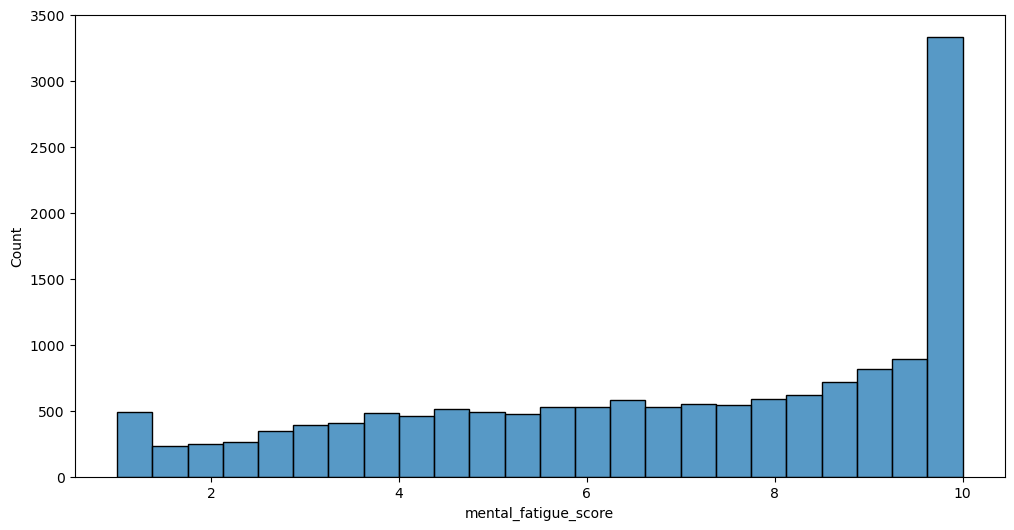

In [85]:
plt.figure(figsize=(12,6))
sns.histplot(df, x='mental_fatigue_score')
plt.show()

In [44]:
#Seleccion de variables categoricas
df_categoricas = df.select_dtypes(include='object').columns
df_categoricas = [col for col in df_categoricas]
df_categoricas

['gender', 'occupation']

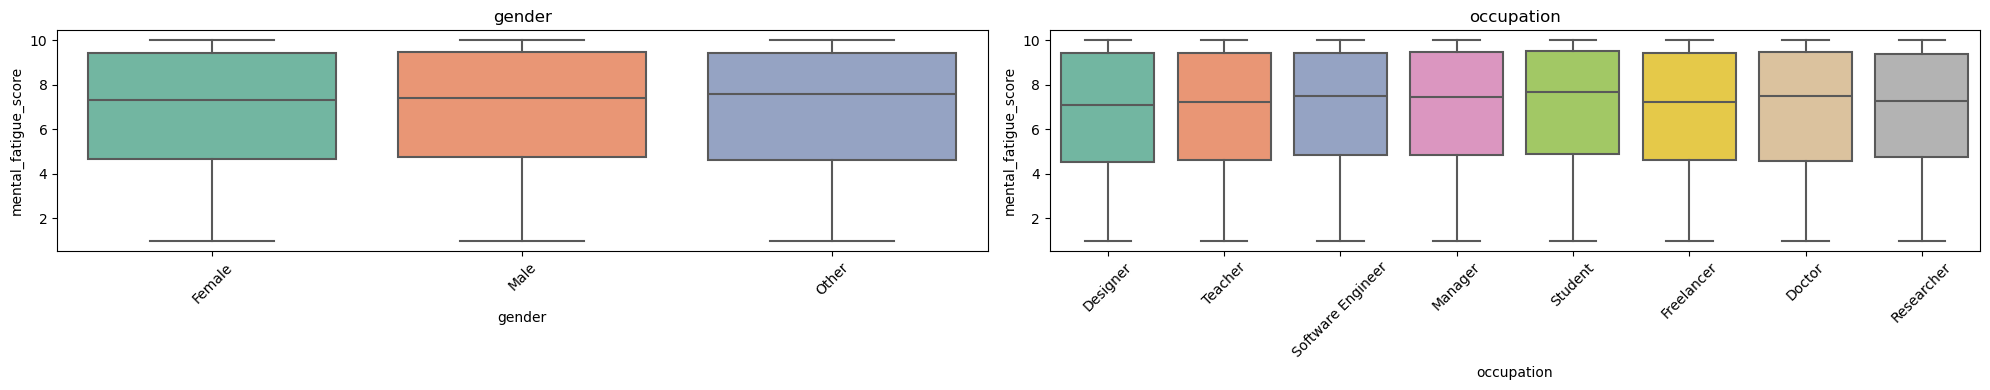

In [ ]:
import math

#Son solo dos variables, se podrian graficar a parte cada una, pero siempre uso esta forma para cuando son mas.
n_cols = 2
n_rows = math.ceil(len(df_categoricas)/n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows*4))
axes = axes.flatten()

for i, col in enumerate(df_categoricas):
    sns.boxplot(
        data= df,
        x = col,
        y = 'mental_fatigue_score',
        ax = axes[i],
        palette = 'Set2')
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [46]:
#Seleccion de variables numericas
df_numericas = df.select_dtypes(exclude='object').columns
df_numericas = [col for col in df_numericas]
df_numericas

['age',
 'daily_screen_time_hours',
 'phone_usage_before_sleep_minutes',
 'sleep_duration_hours',
 'sleep_quality_score',
 'stress_level',
 'caffeine_intake_cups',
 'physical_activity_minutes',
 'notifications_received_per_day',
 'mental_fatigue_score']

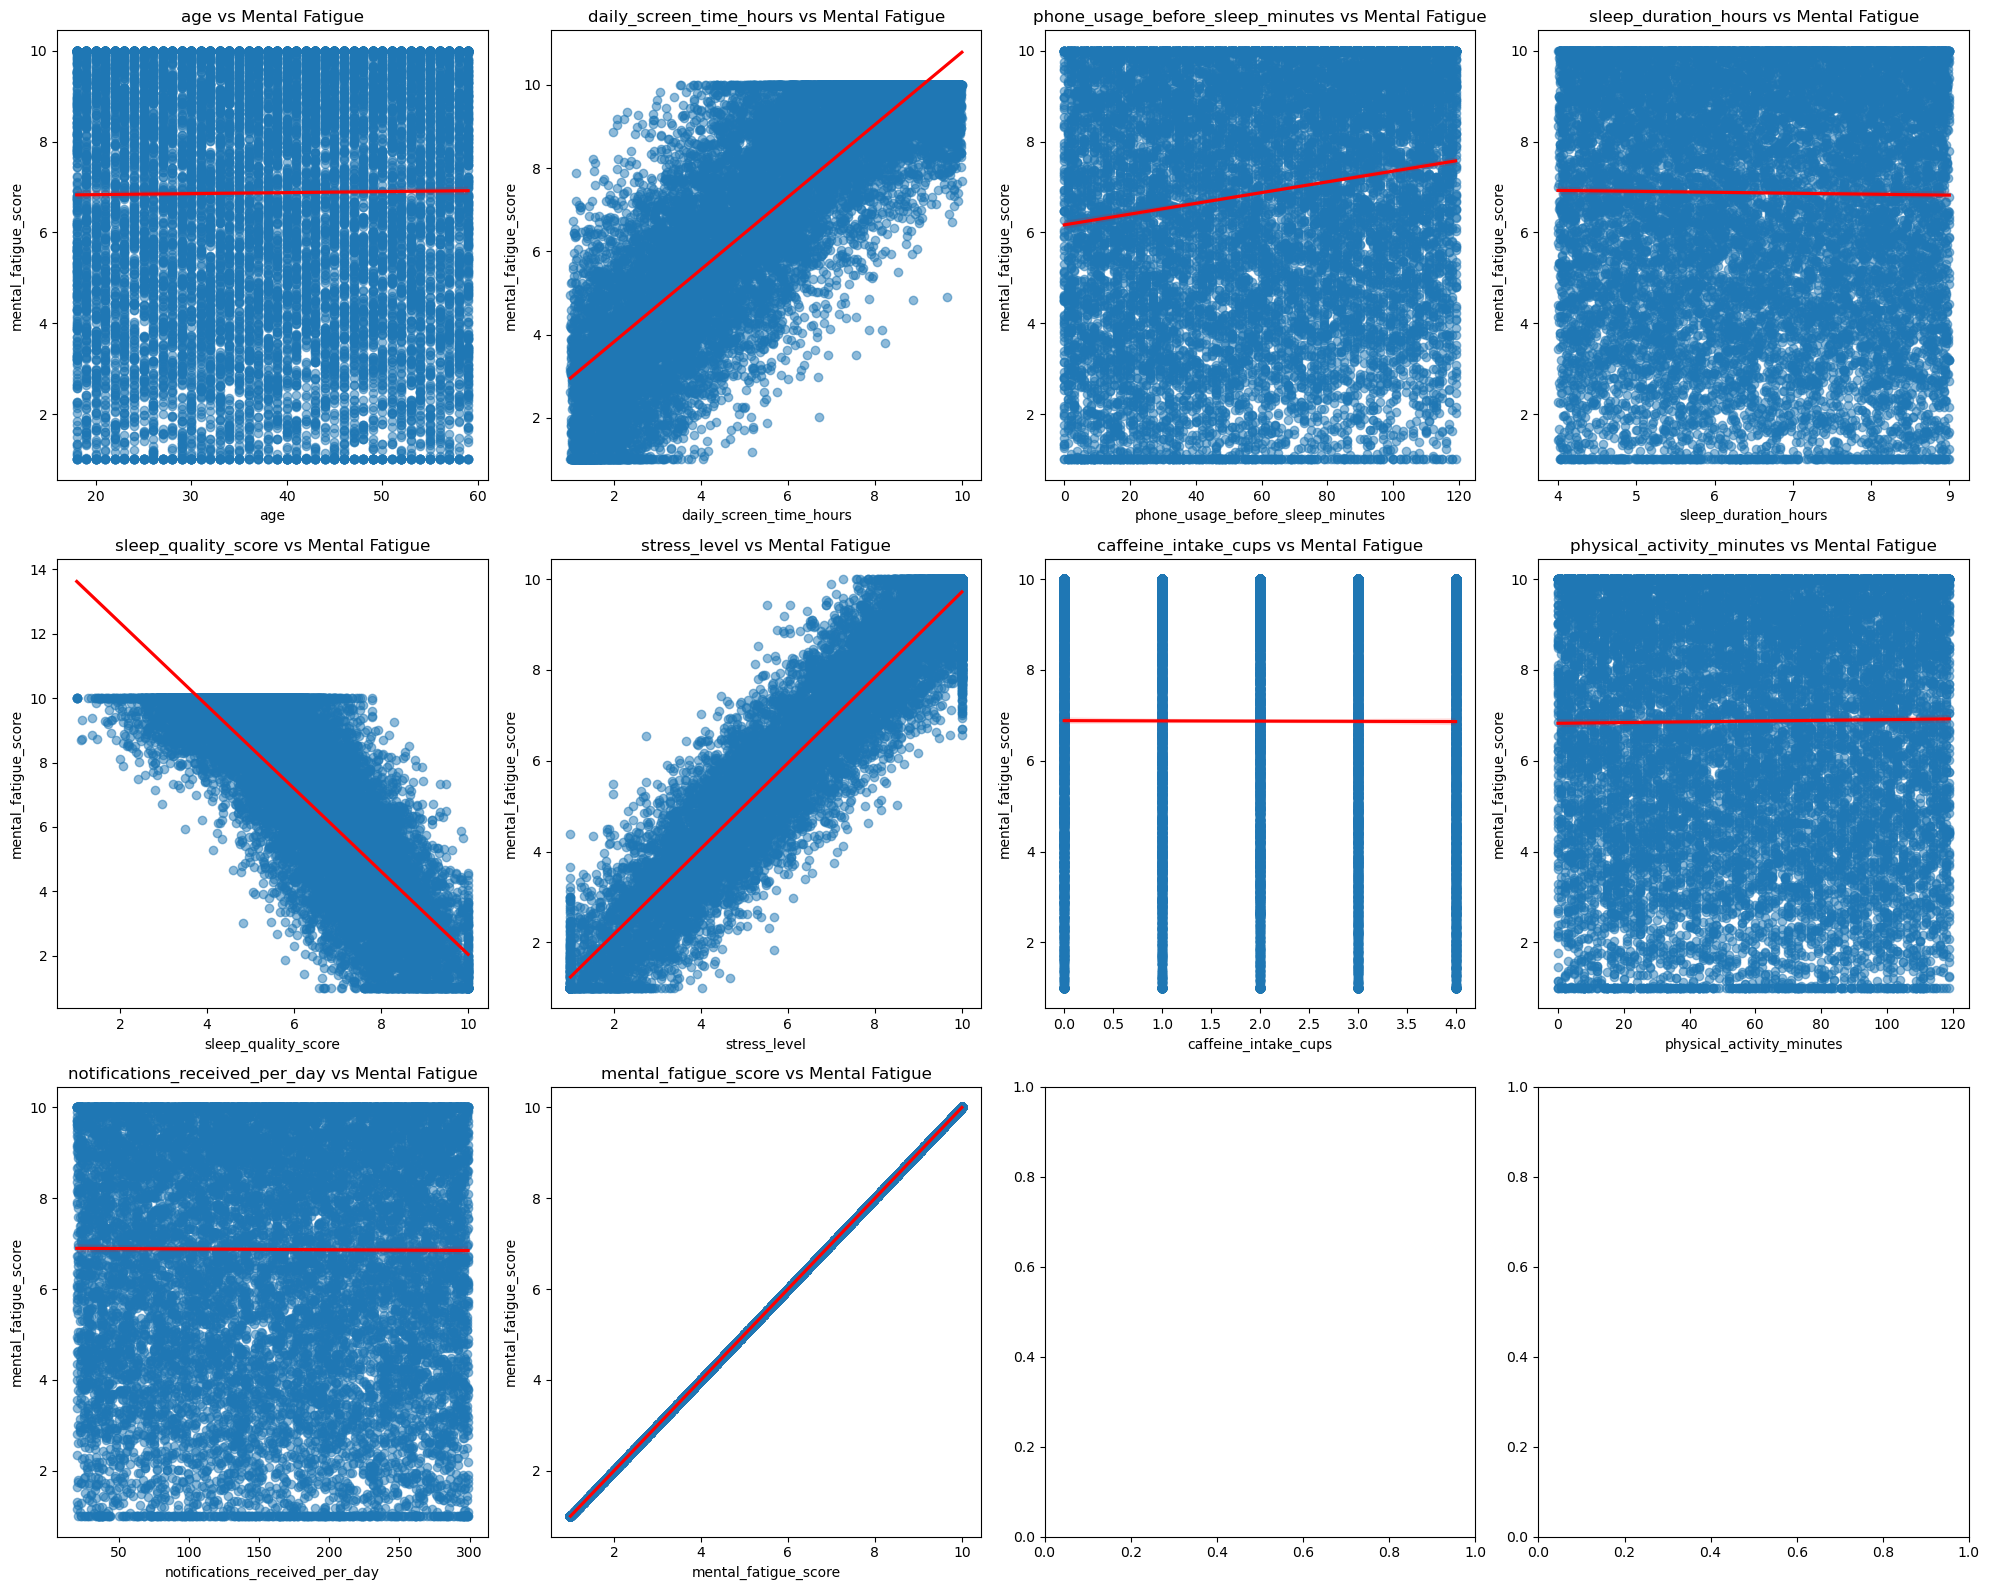

In [ ]:
n_cols = 3
n_rows = math.ceil(len(df_numericas)/n_cols)

fix, axes = plt.subplots(n_cols, n_rows, figsize=(20, n_rows*4))

#Aplanar y guardar en una variable
axes_flat = axes.flatten()


for i, col in enumerate(df_numericas):
    sns.regplot(
        data = df,
        x = col,
        y = 'mental_fatigue_score',
        scatter_kws = {'alpha':0.5},
        line_kws = {'color':'red'},
        ax = axes_flat[i]
    )
    axes_flat[i].set_title(f'{col} vs Mental Fatigue')
        
plt.tight_layout()
plt.show()   
        
        
    
                        

In [ ]:
# correlación de todas las variables con la fatiga mental
correlaciones = df[df_numericas].corr()['mental_fatigue_score'].sort_values(ascending=False)

print("Correlación con Mental Fatigue Score:")
print(correlaciones)

Correlación con Mental Fatigue Score:
mental_fatigue_score                1.000000
stress_level                        0.948768
daily_screen_time_hours             0.828368
phone_usage_before_sleep_minutes    0.150180
physical_activity_minutes           0.010254
age                                 0.009724
caffeine_intake_cups               -0.002722
notifications_received_per_day     -0.005077
sleep_duration_hours               -0.011073
sleep_quality_score                -0.808019
Name: mental_fatigue_score, dtype: float64


In [ ]:
#XGBoosting
import pandas as pd
from sklearn.model_selection import train_test_split
import xgboost as xgb

# 1. Conversion de categóricas a dummies (One-Hot Encoding)
# Nuevas para cada categoría
df_final = pd.get_dummies(df, columns=df_categoricas, drop_first=True)

# 2. Definir X (features) e y (target)
X = df_final.drop(columns=['mental_fatigue_score'])
y = df_final['mental_fatigue_score']

# 3. Division 80/20 entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# modelo con parámetros básicos
model_xgb = xgb.XGBRegressor(
    n_estimators=100,      # Número de árboles
    learning_rate=0.1,     # Paso de aprendizaje (eta)
    max_depth=5,           # Profundidad de los árboles
    random_state=42
)

# Entrenamiento
model_xgb.fit(X_train, y_train)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.1, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=5, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=100, n_jobs=None,
             num_parallel_tree=None, random_state=42, ...)

In [51]:
from sklearn.metrics import mean_squared_error, r2_score

preds = model_xgb.predict(X_test)

rmse = mean_squared_error(y_test, preds, squared=False)
r2 = r2_score(y_test, preds)

print(f"RMSE: {rmse:.4f}")
print(f"R2 Score: {r2:.4f}")

RMSE: 0.8634
R2 Score: 0.9001


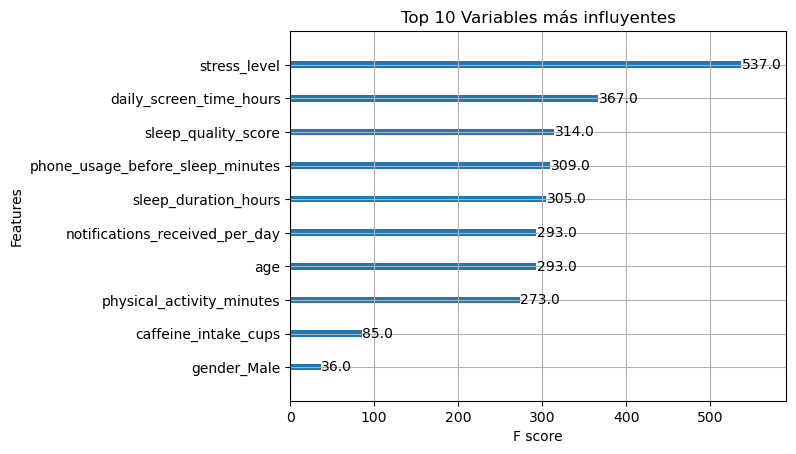

In [52]:
# Importancia de las variables
xgb.plot_importance(model_xgb, max_num_features=10)
plt.title("Top 10 Variables más influyentes")
plt.show()

In [ ]:
# Creamos un ejemplo (ajusta los valores según tus variables reales)
nuevo_dato_dict = {
    'age': 50,
    'daily_screen_time_hours': 8,
    'phone_usage_before_sleep_minutes': 60,
    'sleep_duration_hours': 5,
    'sleep_quality_score': 4,
    'stress_level': 90,
    'caffeine_intake_cups': 5,
    'physical_activity_minutes': 160,
    'notifications_received_per_day': 30,
    'gender': 'Male',
    'occupation': 'Teacher'
}

# DataFrame de una sola fila
df_nuevo = pd.DataFrame([nuevo_dato_dict])

In [ ]:
# Categoricas a dummies
df_nuevo_enc = pd.get_dummies(df_nuevo)

# Añadimos las columnas faltantes que resultaron del One-Hot Encoding en el entrenamiento
# (esto pone en 0 las categorías que no están presentes en este nuevo registro)
df_nuevo_final = df_nuevo_enc.reindex(columns = X_train.columns, fill_value=0)

# Realizamos la predicción
prediccion = model_xgb.predict(df_nuevo_final)

print(f"--- Resultado de la Prueba ---")
print(f"La fatiga mental estimada es: {prediccion[0]:.4f}")

--- Resultado de la Prueba ---
La fatiga mental estimada es: 9.4105


In [66]:
df['occupation'].unique()

array(['Designer', 'Teacher', 'Software Engineer', 'Manager', 'Student',
       'Freelancer', 'Doctor', 'Researcher'], dtype=object)